# SETTING UP ACCESS TO GITHUB (PRESERVED STATE) FOR EVERY NEW RUNTIME

In [ ]:
from google.colab import userdata
import os

git_token = userdata.get('GIT_TOKEN')
git_username = "TalhaShoyo10"
repo_name = "CS-6304_PA0_28100131"
repo_url = f"https://{git_token}@github.com/{git_username}/{repo_name}.git"



if not os.path.exists(repo_name):
  !git clone {repo_url}
  print("Repo did not exist in local file system, cloned from github to initiate work on task.")
else:
  !git -C {repo_name} pull
  print("Repo already existed in local file system, pulled from github to catch up on any remote changes.")

Cloning into 'CS-6304_PA0_28100131'...
remote: Enumerating objects: 110, done.
remote: Counting objects: 100% (110/110), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 110 (delta 33), reused 53 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (110/110), 3.38 MiB | 35.66 MiB/s, done.
Resolving deltas: 100% (33/33), done.
Repo did not exist in local file system, cloned from github to initiate work on task.


Imports and Setup

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import json
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# VARIATIONAL AUTOENCODER

Loading MNIST

In [ ]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Number of training examples: {len(train_dataset)}")
print(f"Number of testing examples: {len(test_dataset)}")
print(f"Number of training batches: {len(train_loader)}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.01MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.44MB/s]

Number of training examples: 60000
Number of testing examples: 10000
Number of training batches: 469


# Building a Basic VAE

Defining the Encoder, Decoder, and Reparameterization Trick

In [ ]:
LATENT_DIM = 2
HIDDEN_DIM = 400
INPUT_DIM = 28 * 28

class VAE(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM):
        super().__init__()

        #Encoder: x -> hidden -> (mu, logvar)
        self.encoder_fc1 = nn.Linear(input_dim, hidden_dim)
        self.encoder_mu = nn.Linear(hidden_dim, latent_dim)
        self.encoder_logvar = nn.Linear(hidden_dim, latent_dim)

        #Decoder: z -> hidden -> reconstructed pixel logits
        self.decoder_fc1 = nn.Linear(latent_dim, hidden_dim)
        self.decoder_out = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.encoder_fc1(x))
        mu = self.encoder_mu(h)
        logvar = self.encoder_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        #z = mu + sigma * epsilon, epsilon ~ N(0, I)
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + std * epsilon
        return z

    def decode(self, z):
        h = F.relu(self.decoder_fc1(z))
        pixel_logits = self.decoder_out(h)
        return pixel_logits

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        pixel_logits = self.decode(z)
        return pixel_logits, mu, logvar


model = VAE().to(device)
print(model)

trainable_paras = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {trainable_paras}")

VAE(
  (encoder_fc1): Linear(in_features=784, out_features=400, bias=True)
  (encoder_mu): Linear(in_features=400, out_features=2, bias=True)
  (encoder_logvar): Linear(in_features=400, out_features=2, bias=True)
  (decoder_fc1): Linear(in_features=2, out_features=400, bias=True)
  (decoder_out): Linear(in_features=400, out_features=784, bias=True)
)
Number of trainable parameters: 631188


Defining the VAE Loss (Negative ELBO)

In [ ]:
def vae_loss(pixel_logits, x, mu, logvar):
    #Reconstruction term: -E_q[log p(x|z)], using a Bernoulli output distribution over pixels
    recon_loss = F.binary_cross_entropy_with_logits(pixel_logits, x, reduction="sum")

    #KL term: closed-form KL divergence between N(mu, sigma^2) and N(0, I)
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = recon_loss + kl_div
    return total_loss, recon_loss, kl_div

Training Loop

In [ ]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, total_recon, total_kl = 0.0, 0.0, 0.0

    for images, _ in loader:
        images = images.view(images.size(0), -1).to(device)

        optimizer.zero_grad()
        pixel_logits, mu, logvar = model(images)
        loss, recon_loss, kl_div = vae_loss(pixel_logits, images, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_div.item()

    n = len(loader.dataset)
    return total_loss / n, total_recon / n, total_kl / n


optimizer = optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 10

history = {"train_loss": [], "recon_loss": [], "kl_loss": []}

for epoch in range(EPOCHS):
    avg_loss, avg_recon, avg_kl = train_epoch(model, train_loader, optimizer, device)
    history["train_loss"].append(avg_loss)
    history["recon_loss"].append(avg_recon)
    history["kl_loss"].append(avg_kl)
    print(f"Epoch {epoch+1}/{EPOCHS} - ELBO Loss: {avg_loss:.4f} (Recon: {avg_recon:.4f}, KL: {avg_kl:.4f})")

Epoch 1/10 - ELBO Loss: 189.5584 (Recon: 184.0537, KL: 5.5046)
Epoch 2/10 - ELBO Loss: 167.7843 (Recon: 162.5019, KL: 5.2823)
Epoch 3/10 - ELBO Loss: 163.1727 (Recon: 157.7611, KL: 5.4115)
Epoch 4/10 - ELBO Loss: 160.6343 (Recon: 155.1471, KL: 5.4872)
Epoch 5/10 - ELBO Loss: 158.9079 (Recon: 153.3734, KL: 5.5345)
Epoch 6/10 - ELBO Loss: 157.6363 (Recon: 152.0323, KL: 5.6039)
Epoch 7/10 - ELBO Loss: 156.6046 (Recon: 150.9567, KL: 5.6478)
Epoch 8/10 - ELBO Loss: 155.7606 (Recon: 150.0862, KL: 5.6743)
Epoch 9/10 - ELBO Loss: 155.0592 (Recon: 149.3364, KL: 5.7228)
Epoch 10/10 - ELBO Loss: 154.3764 (Recon: 148.6243, KL: 5.7521)


Plotting the ELBO Loss Curve

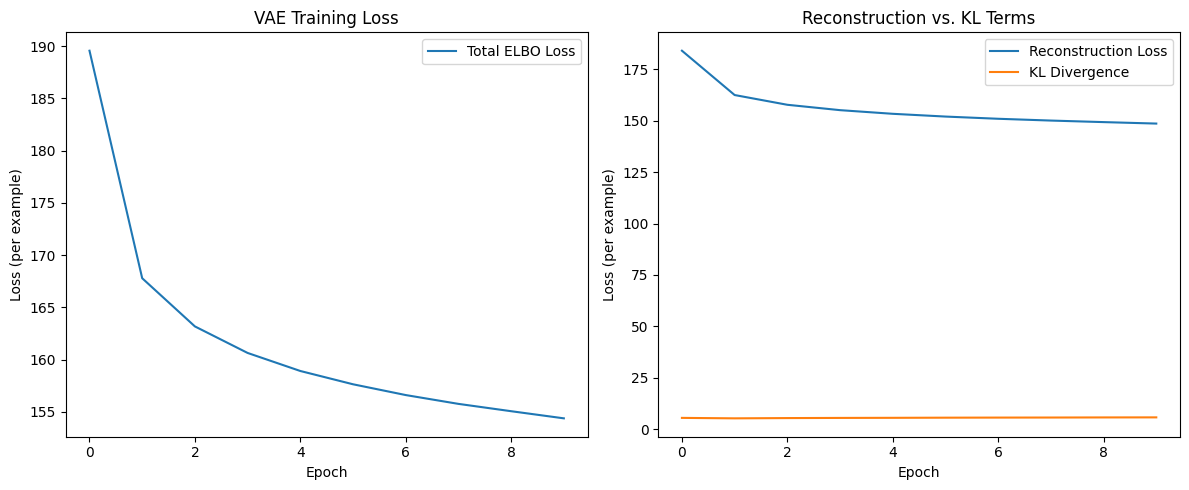

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history["train_loss"], label="Total ELBO Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (per example)")
axes[0].set_title("VAE Training Loss")
axes[0].legend()

axes[1].plot(history["recon_loss"], label="Reconstruction Loss")
axes[1].plot(history["kl_loss"], label="KL Divergence")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss (per example)")
axes[1].set_title("Reconstruction vs. KL Terms")
axes[1].legend()

plt.tight_layout()
plt.savefig("CS-6304_PA0_28100131/results/task4_vae/training_loss.png", dpi=150)
plt.show()

# Analyzing VAE Performance

(a) Latent Space Visualization

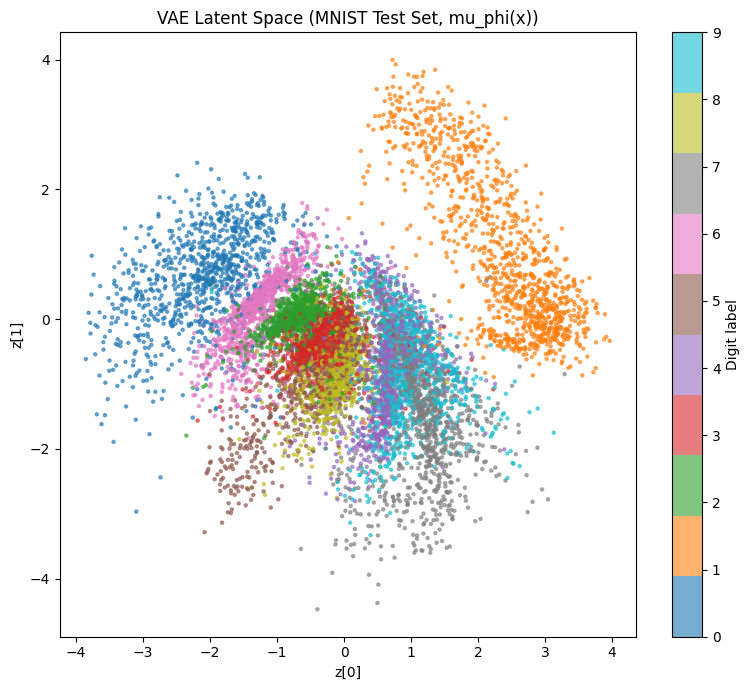

In [ ]:
model.eval()

all_mu = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1).to(device)
        mu, logvar = model.encode(images)
        all_mu.append(mu.cpu())
        all_labels.append(labels)

all_mu = torch.cat(all_mu, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

plt.figure(figsize=(8, 7))
scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1], c=all_labels, cmap="tab10", s=5, alpha=0.6)
plt.colorbar(scatter, ticks=range(10), label="Digit label")
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.title("VAE Latent Space (MNIST Test Set, mu_phi(x))")
plt.tight_layout()
plt.savefig("CS-6304_PA0_28100131/results/task4_vae/latent_space.png", dpi=150)
plt.show()

(b) Reconstruction Quality

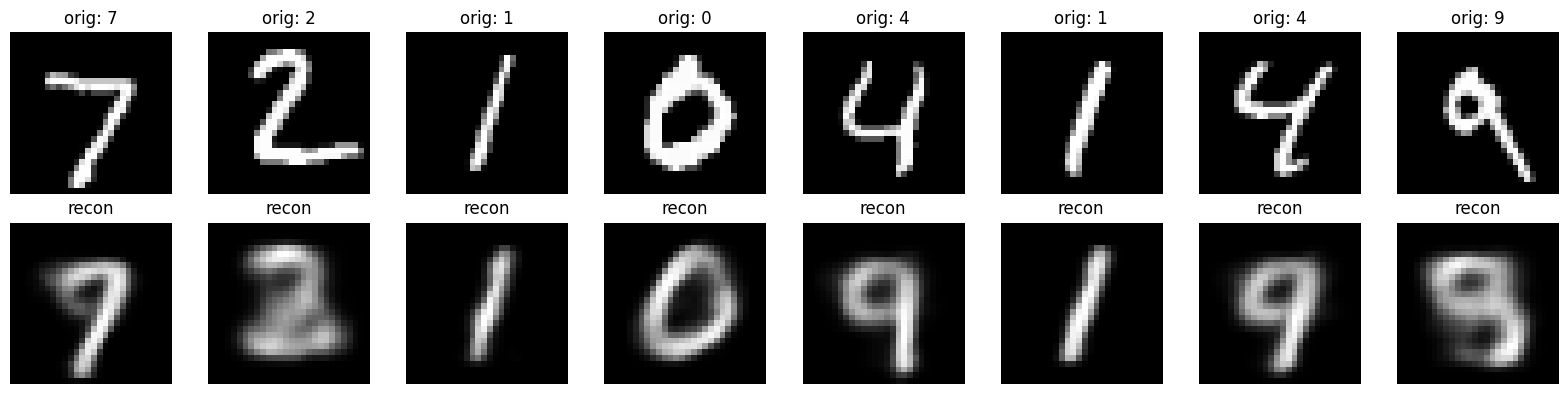

In [ ]:
NUM_RECON_SAMPLES = 8

sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images[:NUM_RECON_SAMPLES]
sample_labels = sample_labels[:NUM_RECON_SAMPLES]

flat_images = sample_images.view(NUM_RECON_SAMPLES, -1).to(device)

with torch.no_grad():
    pixel_logits, mu, logvar = model(flat_images)
    reconstructions = torch.sigmoid(pixel_logits).view(NUM_RECON_SAMPLES, 1, 28, 28).cpu()

fig, axes = plt.subplots(2, NUM_RECON_SAMPLES, figsize=(2 * NUM_RECON_SAMPLES, 4))

for i in range(NUM_RECON_SAMPLES):
    axes[0, i].imshow(sample_images[i].squeeze(), cmap="gray")
    axes[0, i].set_title(f"orig: {sample_labels[i].item()}")
    axes[0, i].axis("off")

    axes[1, i].imshow(reconstructions[i].squeeze(), cmap="gray")
    axes[1, i].set_title("recon")
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("CS-6304_PA0_28100131/results/task4_vae/reconstructions.png", dpi=150)
plt.show()

(c) Generation of New Samples

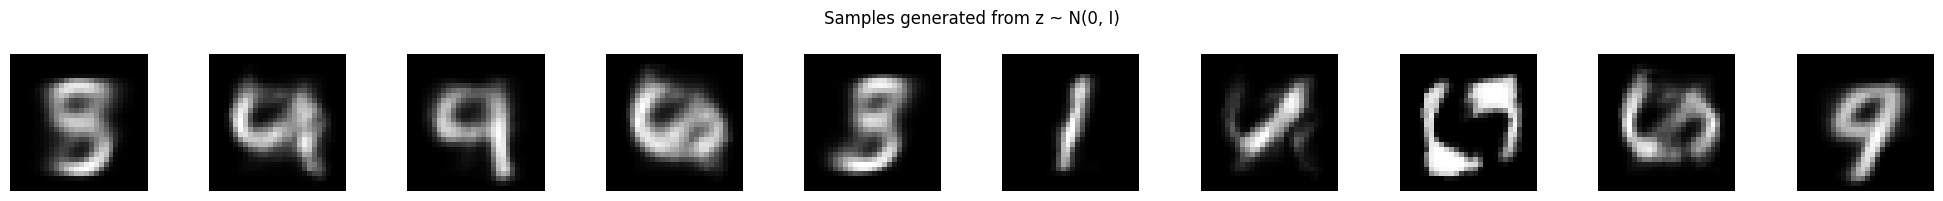

In [ ]:
NUM_GENERATED = 10

with torch.no_grad():
    z_random = torch.randn(NUM_GENERATED, LATENT_DIM).to(device)
    generated_logits = model.decode(z_random)
    generated_images = torch.sigmoid(generated_logits).view(NUM_GENERATED, 1, 28, 28).cpu()

fig, axes = plt.subplots(1, NUM_GENERATED, figsize=(2 * NUM_GENERATED, 2))

for i in range(NUM_GENERATED):
    axes[i].imshow(generated_images[i].squeeze(), cmap="gray")
    axes[i].axis("off")

plt.suptitle("Samples generated from z ~ N(0, I)")
plt.tight_layout()
plt.savefig("CS-6304_PA0_28100131/results/task4_vae/generated_samples.png", dpi=150)
plt.show()

Saving Results

In [ ]:
vae_results = {
    "latent_dim": LATENT_DIM,
    "hidden_dim": HIDDEN_DIM,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": 1e-3,
    "history": history,
    "final_train_loss": history["train_loss"][-1],
}

with open("CS-6304_PA0_28100131/results/task4_vae/vae_results.json", "w") as f:
    json.dump(vae_results, f, indent=2)

torch.save(model.state_dict(), "CS-6304_PA0_28100131/results/task4_vae/vae_model_weights.pt")

print("Results saved successfully !!")

Results saved successfully !!


Checking for Saved Files

In [ ]:
print(os.listdir("CS-6304_PA0_28100131/results/task4_vae"))

['vae_results.json', 'vae_model_weights.pt', 'generated_samples.png', 'latent_space.png', '.gitkeep', 'training_loss.png', 'reconstructions.png']


Git Configuration

In [ ]:
!git config --global user.email "thebenbat5@gmail.com"
!git config --global user.name "TalhaShoyo10"

Commiting work to Github

In [ ]:
commit_message = "Task 4 - VAE implementation, training, and analysis"
!git -C {repo_name} add -A
!git -C {repo_name} commit -m "{commit_message}"
!git -C {repo_name} push https://{git_token}@github.com/{git_username}/{repo_name}.git main

[main 53ba2d4] Task 4 - VAE implementation, training, and analysis
 5 files changed, 46 insertions(+)
 create mode 100644 results/task4_vae/generated_samples.png
 create mode 100644 results/task4_vae/latent_space.png
 create mode 100644 results/task4_vae/reconstructions.png
 create mode 100644 results/task4_vae/training_loss.png
 create mode 100644 results/task4_vae/vae_results.json
Enumerating objects: 12, done.
Counting objects: 100% (12/12), done.
Delta compression using up to 2 threads
Compressing objects: 100% (9/9), done.
Writing objects: 100% (9/9), 618.97 KiB | 18.76 MiB/s, done.
Total 9 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/TalhaShoyo10/CS-6304_PA0_28100131.git
   c3268d9..53ba2d4  main -> main
